In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
def show_image(img):
    """
    可视化 5 通道图像。
    为了方便查看，我们将展示所有 5 个通道的拼接图，
    并在下方展示前 3 个通道合成的 False Color (RGB) 图像。
    """
    # 确保是 Numpy 格式 [C, H, W]
    if isinstance(img, torch.Tensor):
        img = img.detach().cpu().numpy()

    C, H, W = img.shape

    fig = plt.figure(figsize=(12, 5))
    plt.suptitle(f"Image show", fontsize=14, y=1.05)

    # 上半部分：分通道展示 (假设 5 个通道)
    for i in range(min(C, 5)):
        ax = plt.subplot(2, 5, i + 1)
        ax.imshow(img[i], cmap='gray')
        ax.axis('off')
        ax.set_title(f"Ch {i}")

    plt.tight_layout()
    plt.show()

In [2]:
import datasets

dset = datasets.load_from_disk("../../../data/data_g3_z_1k/test_dataset")

/home/dsm/miniconda3/envs/clip/lib/python3.10/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(
/home/dsm/miniconda3/envs/clip/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [25]:
img=dset[0]["image"]

In [9]:
import torch
import numpy as np

def decals_normalize_multiband(image, m=0.03, Q=20.0):
    """
    对多波段天文图像进行 Asinh 归一化，保留原始通道数。

    参数:
        image: 输入张量，形状为 (C, H, W)，C 为波段数 (如 5)
        m: 底数 (Bias)，处理背景噪声
        Q: 软化参数 (Softening parameter)

    返回:
        归一化后的张量，形状保持为 (C, H, W)，数值在 [0, 1] 之间
    """
    # 1. 调整维度方便计算: (C, H, W) -> (H, W, C)
    # 这样最后一个维度就是光谱维度
    image = image.movedim(0, -1)

    # 2. 计算平均强度 (Intensity)
    # 我们不再乘以 RGB_SCALES，而是直接计算所有波段的平均光通量
    # 加 m 是为了提升背景底噪，避免负值和零值问题
    I = torch.mean(torch.clamp(image + m, min=0), dim=-1)

    # 3. 核心 Asinh 变换 (Luptonize)
    # 计算非线性亮度因子
    fI = torch.arcsinh(Q * I) / np.sqrt(Q)

    # 4. 数值稳定性处理
    # 避免除以 0
    I += (I == 0.0) * 1e-6

    # 5. 颜色/光谱比例重构 (Preserving Spectral Ratios)
    # 关键点：将非线性亮度(fI)与线性亮度(I)的比率，应用回原始的每个波段
    # 这样保证了波段之间的相对比率（即光谱斜率/颜色）不变
    image = (image + m) * (fI / I).unsqueeze(-1)

    # 6. 截断到 [0, 1] 并恢复维度
    image = torch.clamp(image, 0, 1)
    return image.movedim(-1, 0)

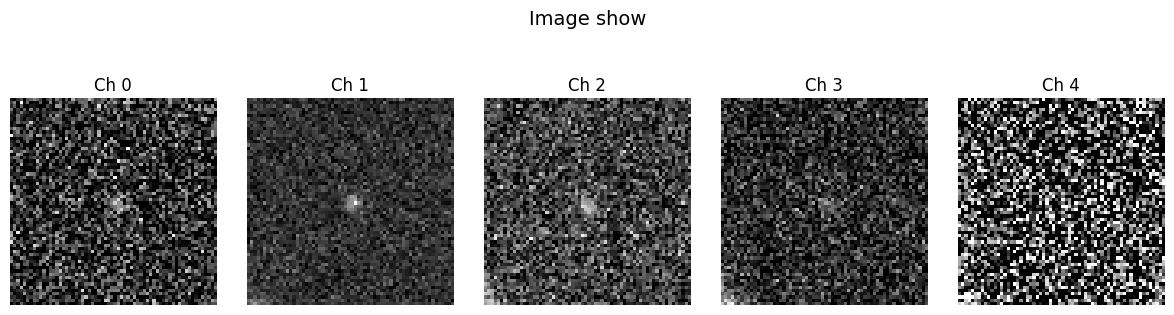

In [10]:
img_asin=decals_normalize_multiband(img)
show_image(img_asin)

In [13]:
# 输出数值范围
print(f"Image range: {img_asin.min().item():.2f} - {img_asin.max().item():.2f}")
print(f"Image range: {img.min().item():.2f} - {img.max().item():.2f}")

Image range: 0.00 - 1.00
Image range: -0.63 - 0.70


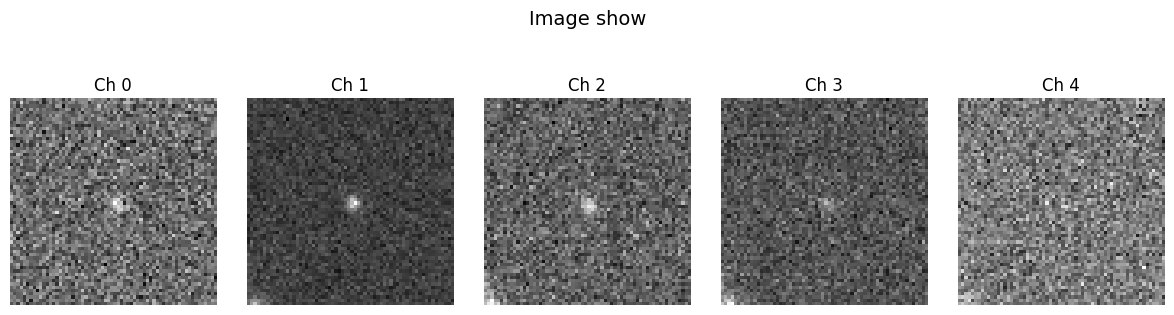

In [11]:
show_image(img)

In [19]:
RGB_SCALES = {
    "u": (2, 1.5),
    "g": (2, 6.0),
    "r": (1, 3.4),
    "i": (0, 1.0),
    "z": (0, 2.2),
}

def decals_to_rgb(image, bands=["g", "r", "z"], scales=None, m=0.03, Q=20.0):
    axes, scales = zip(*[RGB_SCALES[bands[i]] for i in range(len(bands))])
    scales = [scales[i] for i in axes]
    image = image.movedim(0, -1).flip(-1)
    scales = torch.tensor(scales, dtype=torch.float32).to(image.device)
    I = torch.sum(torch.clamp(image * scales + m, min=0), dim=-1) / len(bands)
    fI = torch.arcsinh(Q * I) / np.sqrt(Q)
    I += (I == 0.0) * 1e-6
    image = (image * scales + m) * (fI / I).unsqueeze(-1)
    image = torch.clamp(image, 0, 1)
    return image.movedim(-1, 0)

In [23]:
def sdss_rgb(imgs, bands, scales=None,
             m=0.02, Q=20):
    '''
      *imgs*:   list of 2-d numpy arrays of image pixels (float)
      *bands*:  list of strings with the band names, eg ['g', 'r',' 'z']
      *scales*: dict from band name to (plane, scale), where *plane* is the RGB plane,
                and *scale* multiplies the image pixels
      *m*:      float, an offset added so that pixels containing 0.0 map to a gray value
                rather than black.
      *Q*:      arcsinh scaling value (larger = stronger stretch)

      Returns: H x W x 3 RGB array, floating-point, between 0.0 and 1.0.
    '''

    import numpy as np
    rgbscales = {'u': (2,1.5), #1.0,
                 'g': (2,2.5),
                 'r': (1,1.5),
                 'i': (0,1.0),
                 'z': (0,0.4), #0.3
                 }
    if scales is not None:
        rgbscales.update(scales)

    I = 0
    for img,band in zip(imgs, bands):
        plane,scale = rgbscales[band]
        img = np.maximum(0, img * scale + m)
        I = I + img
    I /= len(bands)

    Q = 20
    fI = np.arcsinh(Q * I) / np.sqrt(Q)
    I += (I == 0.) * 1e-6
    H,W = I.shape
    rgb = np.zeros((H,W,3), np.float32)
    for img,band in zip(imgs, bands):
        plane,scale = rgbscales[band]
        rgb[:,:,plane] = (img * scale + m) * fI / I

    # We saturate to white, while the original SDSS (Lupton et al) color mapping
    # saturates to the color of the object... more scientifically informative, but
    # some say, not as pretty.
    # Can do the SDSS version with something along these lines:
    # # maxrgb = reduce(np.maximum, [R,G,B])
    # # J = (maxrgb > 1.)
    # # R[J] = R[J]/maxrgb[J]
    # # G[J] = G[J]/maxrgb[J]
    # # B[J] = B[J]/maxrgb[J]
    # rgb = np.dstack((R,G,B))

    rgb = np.clip(rgb, 0, 1)
    return rgb

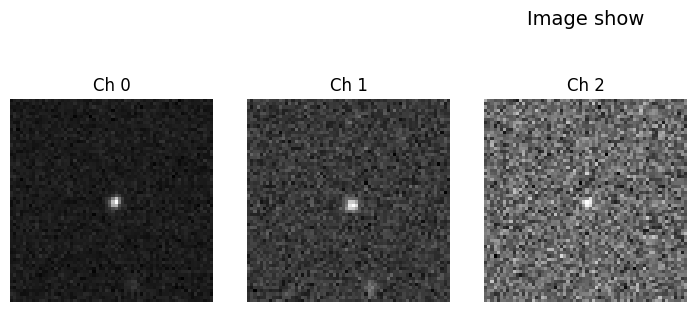

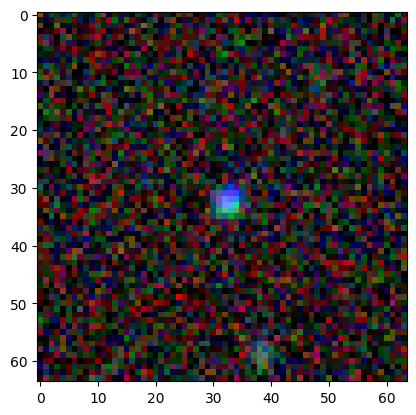

In [36]:
#取出img中的1,2,4通道
img=dset[5]['image']
img_3=torch.stack([img[1],img[2],img[4]],dim=0)
show_image(img_3)
# img_rgb=decals_to_rgb(img_3)
img_rgb=sdss_rgb(img_3,["g","r","z"])
# show_image(img_rgb)
plt.imshow(img_rgb)